In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os


In [84]:
EDA_DIR = os.path.dirname(os.path.abspath('.'))
SRC_DIR = os.path.dirname(EDA_DIR)
DATA_DIR = os.path.join(SRC_DIR, 'data')
DATA_DIR

'/Users/viniciusrocha/Desktop/FIAP/ano2/challenge/challenge-locaweb/data'

In [85]:
df = pd.read_excel(os.path.join(DATA_DIR, 'LW-DATASET.xlsx'))

In [86]:
df.head()

,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?
0,INC8654273,3 - Média,NaN,NaN,NaN,Team14,IC00001,2025-12-31 23:45:18,NaT,2025-12-31 23:45:32,14,NaN,Problem: Apache Busy Workers,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
1,INC8654270,4 - Baixa,NaN,NaN,NaN,Team14,IC00002,2025-12-31 23:39:36,NaT,2025-12-31 23:43:05,209,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
2,INC8654264,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:10,NaT,2025-12-31 23:25:00,110,NaN,Problem: Alarm Application Monitoring database...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
3,INC8654263,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:07,NaT,2025-12-31 23:24:57,110,NaN,Problem: Alarm Application Monitoring coupons ...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
4,INC8654262,4 - Baixa,NaN,NaN,NaN,Team14,IC00003,2025-12-31 23:23:05,NaT,2025-12-31 23:23:47,42,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN


In [87]:
df.shape

(122543, 19)

In [88]:
df.dtypes

Número                             str
Prioridade                         str
Produto                            str
Categoria                          str
Subcategoria                       str
Grupo designado                    str
Item de configuração               str
Aberto                  datetime64[us]
Resolvido               datetime64[us]
Encerrado               datetime64[us]
Duração                          int64
Código de fechamento               str
Descrição resumida                 str
Solução                            str
Aberto por                         str
Incidente Pai                      str
Status                             str
Entrou para KPI?                   str
KPI Violado?                       str
dtype: object

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122543 entries, 0 to 122542
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Número                122543 non-null  str           
 1   Prioridade            122543 non-null  str           
 2   Produto               44608 non-null   str           
 3   Categoria             44822 non-null   str           
 4   Subcategoria          44823 non-null   str           
 5   Grupo designado       122543 non-null  str           
 6   Item de configuração  120763 non-null  str           
 7   Aberto                122543 non-null  datetime64[us]
 8   Resolvido             40241 non-null   datetime64[us]
 9   Encerrado             122543 non-null  datetime64[us]
 10  Duração               122543 non-null  int64         
 11  Código de fechamento  40804 non-null   str           
 12  Descrição resumida    122543 non-null  str           
 13  Solução   

In [90]:
colunas = df.columns.tolist()
nulos = df.isnull().sum()
pct_nulos = round(nulos/len(df) * 100,2)

df_nulos = pd.DataFrame({ 
    'Nulos': nulos,
    '% nulos': pct_nulos
    }
)
df_nulos

,Nulos,% nulos
Número,0,0.00
Prioridade,0,0.00
Produto,77935,63.60
Categoria,77721,63.42
Subcategoria,77720,63.42
Grupo designado,0,0.00
Item de configuração,1780,1.45
Aberto,0,0.00
Resolvido,82302,67.16
Encerrado,0,0.00


In [91]:
print(f"Duplicatas: {df.duplicated().sum()}")

Duplicatas: 0


In [92]:
cat_features = df.select_dtypes(include=['string','object']).columns
for col in cat_features:
    print(f'Coluna: {col} \nValores distintos: {df[col].nunique()} ')
    print()

Coluna: Número 
Valores distintos: 122543 

Coluna: Prioridade 
Valores distintos: 5 

Coluna: Produto 
Valores distintos: 51 

Coluna: Categoria 
Valores distintos: 141 

Coluna: Subcategoria 
Valores distintos: 447 

Coluna: Grupo designado 
Valores distintos: 17 

Coluna: Item de configuração 
Valores distintos: 9171 

Coluna: Código de fechamento 
Valores distintos: 17 

Coluna: Descrição resumida 
Valores distintos: 18021 

Coluna: Solução 
Valores distintos: 2 

Coluna: Aberto por 
Valores distintos: 2 

Coluna: Incidente Pai 
Valores distintos: 3326 

Coluna: Status 
Valores distintos: 4 

Coluna: Entrou para KPI? 
Valores distintos: 2 

Coluna: KPI Violado? 
Valores distintos: 2 



In [93]:
df['data_abertura'] = df['Aberto'].dt.date
df['hora_abertura'] = df['Aberto'].dt.hour
df['dia_semana_abertura']  = df['Aberto'].dt.dayofweek  # 0=seg, 6=dom
df['nome_dia_abertura']    = df['Aberto'].dt.day_name()

df['mes_abertura'] = df['Aberto'].dt.month
df['ano_abertura']  = df['Aberto'].dt.year

df['data_abertura'].head()

0    2025-12-31
1    2025-12-31
2    2025-12-31
3    2025-12-31
4    2025-12-31
Name: data_abertura, dtype: object

In [94]:
print(f'Data mínima: {df['data_abertura'].min()}')
print(f'Data máxima: {df['data_abertura'].max()}')
print(f"Total de dias: {(df['data_abertura'].max() - df['data_abertura'].min()).days}")


Data mínima: 2023-01-02
Data máxima: 2025-12-31
Total de dias: 1094


In [95]:
incidentes_por_dia = df.groupby('data_abertura').size().reset_index(name='Total')
incidentes_por_dia

,data_abertura,Total
0,2023-01-02,1
1,2023-01-09,1
2,2023-01-11,2
3,2023-01-16,1
4,2023-01-17,2
...,...,...
639,2025-12-27,1027
640,2025-12-28,829
641,2025-12-29,921
642,2025-12-30,866


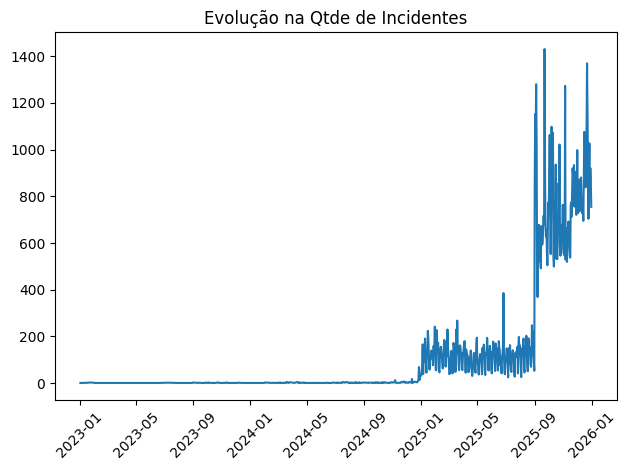

In [96]:
plt.plot(incidentes_por_dia['data_abertura'],incidentes_por_dia['Total'])
plt.title('Evolução na Qtde de Incidentes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [97]:
cat_features

Index(['Número', 'Prioridade', 'Produto', 'Categoria', 'Subcategoria',
       'Grupo designado', 'Item de configuração', 'Código de fechamento',
       'Descrição resumida', 'Solução', 'Aberto por', 'Incidente Pai',
       'Status', 'Entrou para KPI?', 'KPI Violado?'],
      dtype='str')

In [98]:
indidentes_prioridade = df.groupby('Prioridade').size().reset_index(name='Total')
indidentes_prioridade

,Prioridade,Total
0,1 - Crítica,1
1,2 - Alta,15649
2,3 - Média,41732
3,4 - Baixa,64828
4,5 - Muito Baixa,333


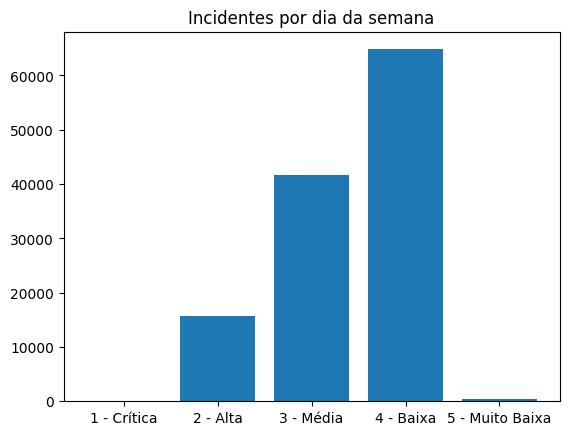

In [99]:
plt.bar(indidentes_prioridade['Prioridade'], indidentes_prioridade['Total'])
plt.title('Incidentes por dia da semana')
plt.show()

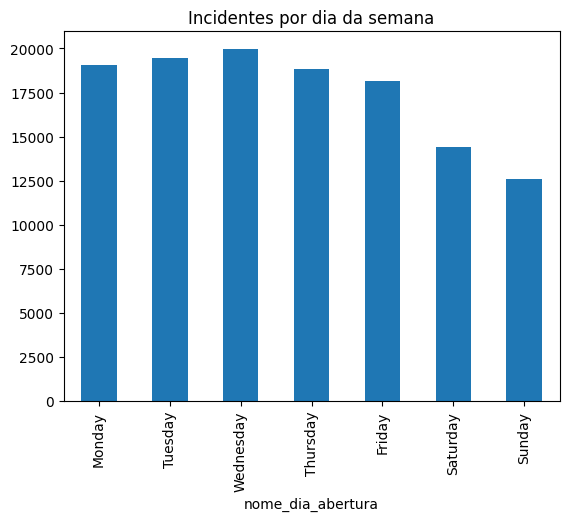

In [100]:
df.groupby(['nome_dia_abertura']).size().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
]).plot(kind='bar',title='Incidentes por dia da semana')
plt.show()

<Axes: title={'center': 'Top 10 Categorias'}, ylabel='Categoria'>

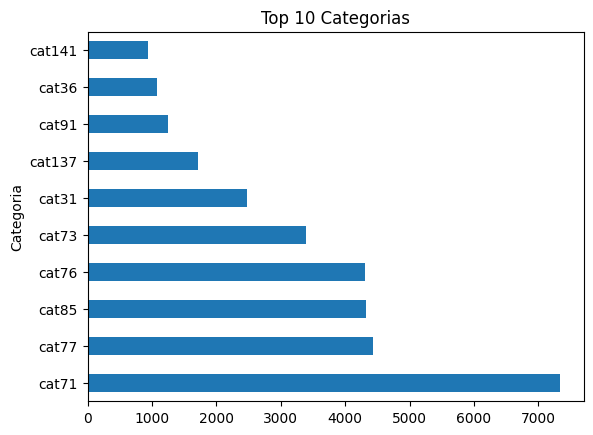

In [101]:
# --- Top 10 categorias com mais incidentes ---
df['Categoria'].value_counts().head(10).plot(
    kind='barh', title='Top 10 Categorias'
)

Text(0.5, 1.0, 'Concentração de incidentes: dia vs hora')

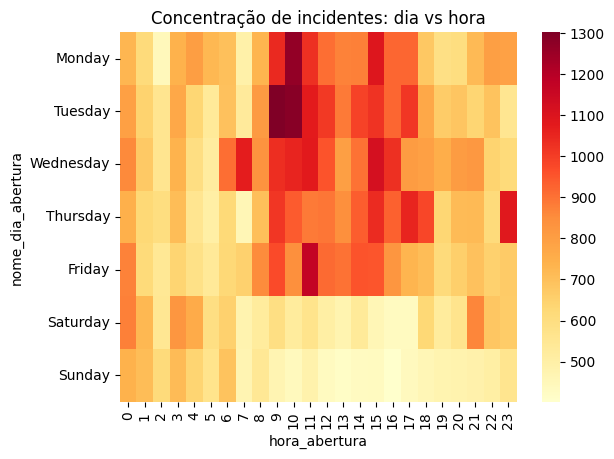

In [102]:
# --- Heatmap: dia da semana x hora do dia ---
pivot = df.pivot_table(
    index='nome_dia_abertura', 
    columns='hora_abertura', 
    values='Número',  # coluna de id
    aggfunc='count'
).reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

sns.heatmap(pivot, cmap='YlOrRd', annot=False)
plt.title('Concentração de incidentes: dia vs hora')

In [103]:
# Essa é a base para o modelo de ML
serie = (
    df.groupby(['data_abertura', 'Prioridade'])
    .size()
    .reset_index(name='qtd_incidentes')
    .pivot(index='data_abertura', columns='Prioridade', values='qtd_incidentes')
    .fillna(0)
    .reset_index()
)
serie


Prioridade,data_abertura,1 - Crítica,2 - Alta,3 - Média,4 - Baixa,5 - Muito Baixa
0,2023-01-02,0.0,0.0,1.0,0.0,0.0
1,2023-01-09,0.0,0.0,1.0,0.0,0.0
2,2023-01-11,0.0,0.0,2.0,0.0,0.0
3,2023-01-16,0.0,0.0,1.0,0.0,0.0
4,2023-01-17,0.0,0.0,2.0,0.0,0.0
...,...,...,...,...,...,...
639,2025-12-27,0.0,53.0,502.0,472.0,0.0
640,2025-12-28,0.0,46.0,391.0,392.0,0.0
641,2025-12-29,0.0,57.0,515.0,349.0,0.0
642,2025-12-30,0.0,29.0,468.0,369.0,0.0


In [107]:

# Renomeia para ficar limpo
serie.columns.name = None
serie = serie.rename(columns={
    'P1': 'qtd_p1',
    'P2': 'qtd_p2', 
    'P3': 'qtd_p3'
})

serie.head()
# Esse dataframe vai ser a entrada do seu modelo

,data_abertura,1 - Crítica,2 - Alta,3 - Média,4 - Baixa,5 - Muito Baixa
0,2023-01-02,0.0,0.0,1.0,0.0,0.0
1,2023-01-09,0.0,0.0,1.0,0.0,0.0
2,2023-01-11,0.0,0.0,2.0,0.0,0.0
3,2023-01-16,0.0,0.0,1.0,0.0,0.0
4,2023-01-17,0.0,0.0,2.0,0.0,0.0
